# LAB 4 ANN classification - Sentinel 2 patches: Urban vs Forest


Goal of this lab is to create an ANN that correctly classify pathec of sattelite photo to 1 of 2 different classes: urban or forest.

The whole idea of this ANN can be thought as a function f(x) -> (0,1) where x is a given patch and when inserted into function f returns either 0 or 1 (forest, urban).


Lets start with creating training dataset:

In [1]:
import glob
import rasterio
import numpy as np
from rasterio.windows import from_bounds
from pyproj import Transformer


In [2]:
folder = "/home/scoora/studies/ml/ML_for_space_tech/data/S2A_MSIL2A_20241018T095031_N0511_R079_T34UDA_20241018T124947.SAFE/GRANULE/L2A_T34UDA_A048696_20241018T095240/IMG_DATA/R10m/"

band_paths = {
    b: glob.glob(f"{folder}/*_{b}_10m.jp2")[0]
    for b in ["B04", "B03", "B02", "B08"]
}

print("Found bands:", band_paths)


Found bands: {'B04': '/home/scoora/studies/ml/ML_for_space_tech/data/S2A_MSIL2A_20241018T095031_N0511_R079_T34UDA_20241018T124947.SAFE/GRANULE/L2A_T34UDA_A048696_20241018T095240/IMG_DATA/R10m/T34UDA_20241018T095031_B04_10m.jp2', 'B03': '/home/scoora/studies/ml/ML_for_space_tech/data/S2A_MSIL2A_20241018T095031_N0511_R079_T34UDA_20241018T124947.SAFE/GRANULE/L2A_T34UDA_A048696_20241018T095240/IMG_DATA/R10m/T34UDA_20241018T095031_B03_10m.jp2', 'B02': '/home/scoora/studies/ml/ML_for_space_tech/data/S2A_MSIL2A_20241018T095031_N0511_R079_T34UDA_20241018T124947.SAFE/GRANULE/L2A_T34UDA_A048696_20241018T095240/IMG_DATA/R10m/T34UDA_20241018T095031_B02_10m.jp2', 'B08': '/home/scoora/studies/ml/ML_for_space_tech/data/S2A_MSIL2A_20241018T095031_N0511_R079_T34UDA_20241018T124947.SAFE/GRANULE/L2A_T34UDA_A048696_20241018T095240/IMG_DATA/R10m/T34UDA_20241018T095031_B08_10m.jp2'}


In [3]:
def read_crop(path, bounds):
    with rasterio.open(path) as src:
        window = from_bounds(*bounds, transform=src.transform)
        data = src.read(1, window=window)
    return data

transformer = Transformer.from_crs("EPSG:4326", "EPSG:32634", always_xy=True)

PATCH_SIZE = 200     # ANN requirement
PIXEL_SIZE = 10      # Sentinel-2 10m resolution
HALF = PATCH_SIZE//2

def extract_patch(lat, lon):
    # Convert lat/lon → UTM
    x, y = transformer.transform(lon, lat)
    
    # Build bounding box in meters
    dx = HALF * PIXEL_SIZE
    dy = HALF * PIXEL_SIZE

    xmin, ymin = x - dx, y - dy
    xmax, ymax = x + dx, y + dy

    # load bands and normalize 
    scale = 1.0 / 10000.0
    b4 = read_crop(band_paths["B04"], (xmin, ymin, xmax, ymax)).astype(np.float32) * scale
    b3 = read_crop(band_paths["B03"], (xmin, ymin, xmax, ymax)).astype(np.float32) * scale
    b2 = read_crop(band_paths["B02"], (xmin, ymin, xmax, ymax)).astype(np.float32) * scale
    b8 = read_crop(band_paths["B08"], (xmin, ymin, xmax, ymax)).astype(np.float32) * scale
    patch = np.dstack((b4, b3, b2, b8))

    if patch.shape != (PATCH_SIZE, PATCH_SIZE, 4):
        return None  # skip incomplete borders

    return patch


hand picking centers of patches

In [4]:
urban_centers = [
    (50.06143, 19.93722),   # Rynek Główny
    (50.0645,  19.9480),    # Galeria Krakowska / Dworzec
    (50.0545,  19.9360),    # Kazimierz
    (50.0475,  19.9450),    # Podgórze
    (50.0730,  19.9400),    # Old Town north
    (50.0860,  19.9200),    # Krowodrza
    (50.0800,  19.9600),    # Grzegórzki
    (50.0700,  19.9800),    # Dąbie
    (50.0805,  19.8900),    # Bronowice
    (50.0950,  19.9300),    # Prądnik Biały
    (50.0240,  19.9500),    # Kurdwanów
    (50.0370,  19.9400),    # Łagiewniki
    (50.0700,  20.0000),    # Mogilska / Czyżyny
    (50.0780,  20.0200),    # Nowa Huta – central
    (50.0900,  20.0300),    # Nowa Huta – east
    (50.0580,  20.0100),    # Płaszów
    (50.0500,  19.9800),    # Zabłocie / industrial
    (50.0300,  19.9700),    # Ruczaj / Kampus UJ
]

forest_centers = [
    (50.0300, 20.3400),   # Puszcza Niepołomicka center
    (50.0250, 20.3600),
    (50.0150, 20.3300),
    (50.0400, 20.3500),
    (50.0350, 20.3200),
    (50.0200, 20.3100),
    (50.0100, 20.3500),
    (50.0000, 20.3400),
    (50.0450, 20.3700),
    (50.0280, 20.3800),
    (50.0180, 20.2950),
    (50.0080, 20.3050),
    (50.0380, 20.3050),
    (50.0480, 20.3300),
    (49.9980, 20.3200),
    (50.0120, 20.3650),
    (50.0220, 20.3950),
    (50.0320, 20.3150),
]


Classification:

In [5]:
X = []
y = []

# URBAN = 1
for lat, lon in urban_centers:
    patch = extract_patch(lat, lon)
    if patch is not None:
        X.append(patch)
        y.append(1)

# FOREST = 0
for lat, lon in forest_centers:
    patch = extract_patch(lat, lon)
    if patch is not None:
        X.append(patch)
        y.append(0)

X = np.stack(X)
y = np.array(y).astype("float32")

print("Dataset shape:", X.shape)
print("Labels:", y)


Dataset shape: (36, 200, 200, 4)
Labels: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


Splitting to train and test datasets, the validation dataset will be added in the model training.

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=0)

Creating baseline model:

In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Build simple ANN
def build_simple_ann(input_shape=(200, 200, 4)):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Flatten(),                      # Flatten the image to a vector
        layers.Dense(64, activation="relu"),   # Hidden layer with 64 neurons
        layers.Dense(1, activation="sigmoid")  # Output layer for binary classification
    ])

    # Compile with Adam + binary crossentropy
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

# Create the model
ann_model = build_simple_ann()
ann_model.summary()


2025-11-13 17:43:00.188359: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-13 17:43:00.501649: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-13 17:43:01.771628: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
E0000 00:00:1763052182.542709  228585 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1763052182.553277  228585 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are install

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 160000)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │    10,240,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,240,129 (39.06 MB)

 Trainable params: 10,240,129 (39.06 MB)

 Non-trainable params: 0 (0.00 B)

## Training the model:

In [ ]:
history = ann_model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,# adding validation dataset (20% of test dataset)
    verbose=2
)


Epoch 1/20
1/1 - 1s - 766ms/step - accuracy: 0.5455 - loss: 0.6915 - val_accuracy: 0.6667 - val_loss: 5.1628
Epoch 2/20
1/1 - 0s - 163ms/step - accuracy: 0.4545 - loss: 8.2590 - val_accuracy: 0.3333 - val_loss: 15.5696
Epoch 3/20
1/1 - 0s - 162ms/step - accuracy: 0.5455 - loss: 10.3226 - val_accuracy: 0.3333 - val_loss: 15.8117
Epoch 4/20
1/1 - 0s - 162ms/step - accuracy: 0.5455 - loss: 10.4004 - val_accuracy: 0.3333 - val_loss: 8.6646
Epoch 5/20
1/1 - 0s - 158ms/step - accuracy: 0.5455 - loss: 5.5132 - val_accuracy: 0.6667 - val_loss: 0.7173
Epoch 6/20
1/1 - 0s - 161ms/step - accuracy: 0.4545 - loss: 1.0614 - val_accuracy: 0.6667 - val_loss: 2.2934
Epoch 7/20
1/1 - 0s - 163ms/step - accuracy: 0.4545 - loss: 3.6916 - val_accuracy: 0.6667 - val_loss: 1.3549
Epoch 8/20
1/1 - 0s - 159ms/step - accuracy: 0.4545 - loss: 2.0766 - val_accuracy: 0.3333 - val_loss: 1.3109
Epoch 9/20
1/1 - 0s - 171ms/step - accuracy: 0.7273 - loss: 0.4561 - val_accuracy: 0.3333 - val_loss: 4.0057
Epoch 10/20
1/1

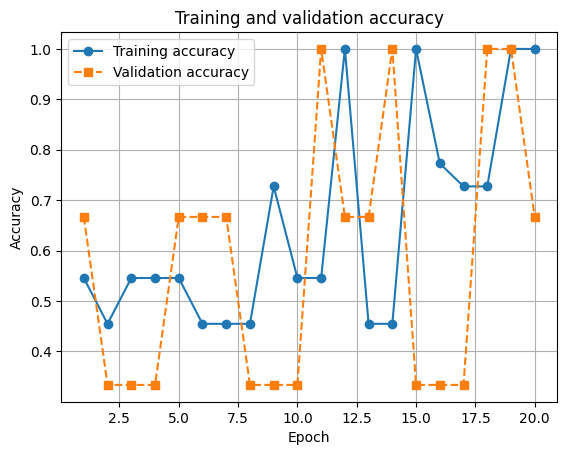

In [10]:
import matplotlib.pyplot as plt

# history.history is a dict with keys: 'loss', 'accuracy', 'val_loss', 'val_accuracy'
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
epochs = range(1, len(acc) + 1)

plt.figure()
plt.plot(epochs, acc, "o-", label="Training accuracy")
plt.plot(epochs, val_acc, "s--", label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.grid(True)
plt.show()


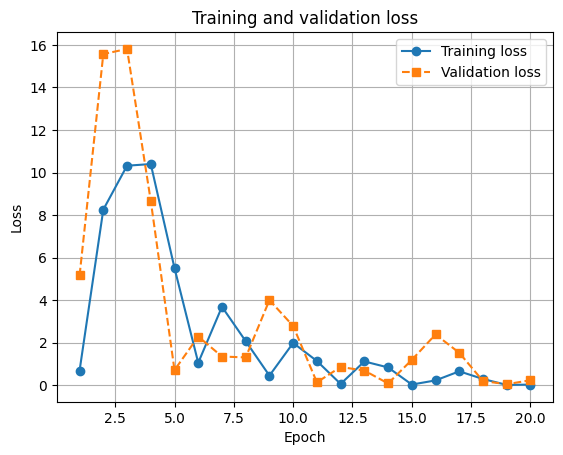

In [11]:
loss = history.history["loss"]
val_loss = history.history["val_loss"]

plt.figure()
plt.plot(epochs, loss, "o-", label="Training loss")
plt.plot(epochs, val_loss, "s--", label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and validation loss")
plt.legend()
plt.grid(True)
plt.show()


## Five differnet variation 
| Experiment    | Change Made                     |
| ------------- | ------------------------------- | 
| Baseline ANN  | 1 hidden layer (64 neurons)     | 
| More neurons  | Hidden layer = 128 neurons      | 
| Two layers    | 2 hidden layers (64 + 32)       | 
| With dropout  | Dropout(0.5) after hidden layer | 
| SGD optimizer | Optimizer changed → SGD         |



Running: baseline
baseline accuracy: 0.5000


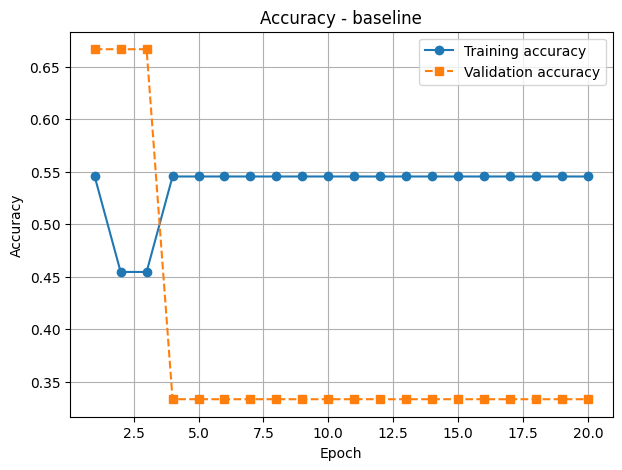

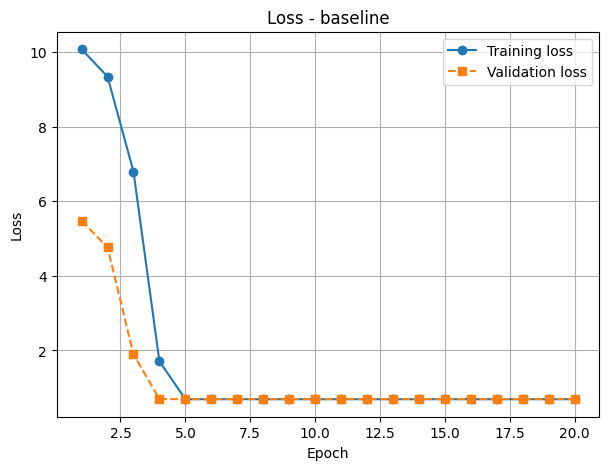


Running: more_neurons
more_neurons accuracy: 1.0000


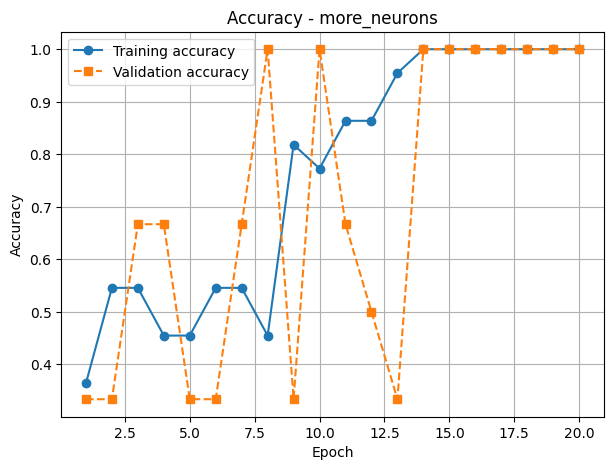

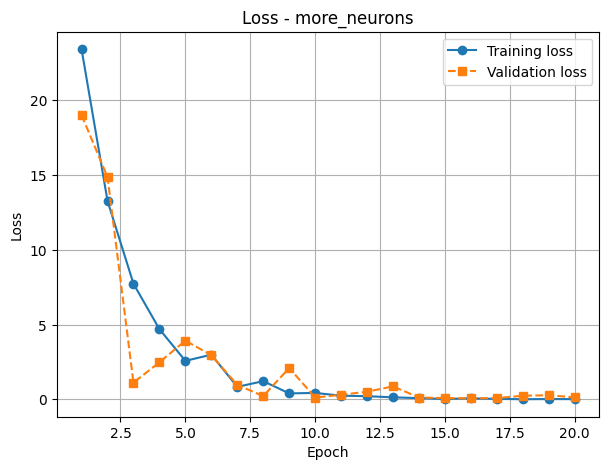


Running: two_layers
two_layers accuracy: 1.0000


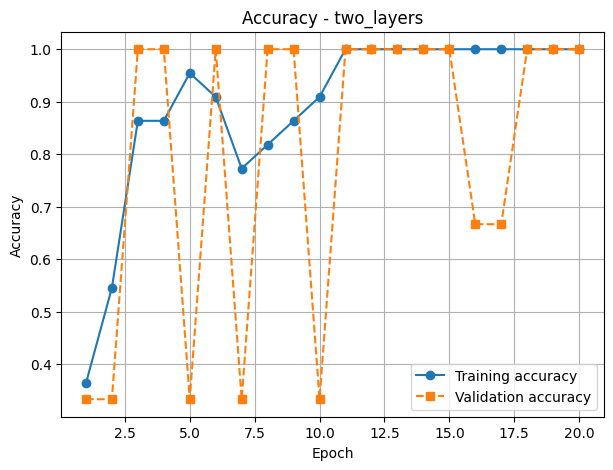

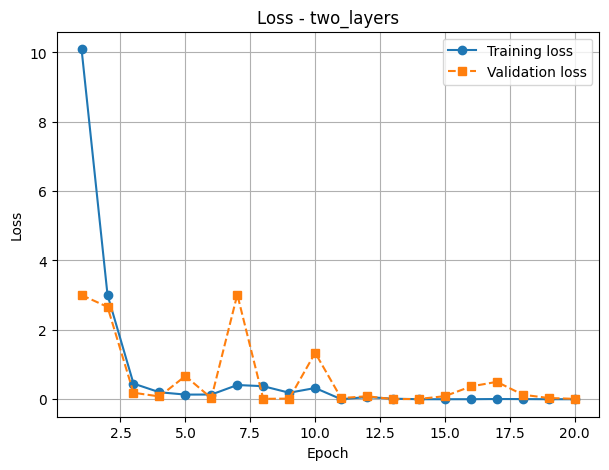


Running: with_dropout
with_dropout accuracy: 1.0000


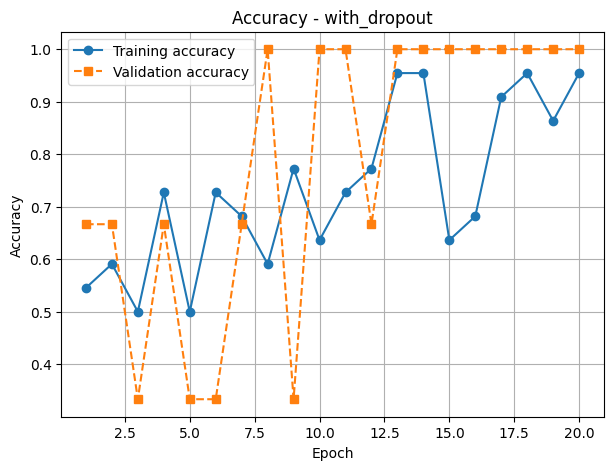

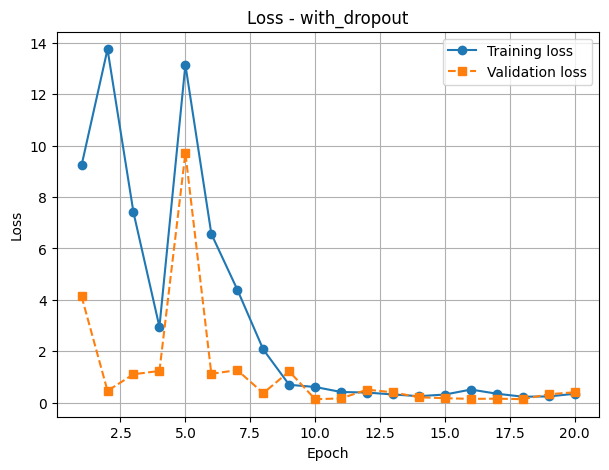


Running: sgd_optimizer
sgd_optimizer accuracy: 0.6250


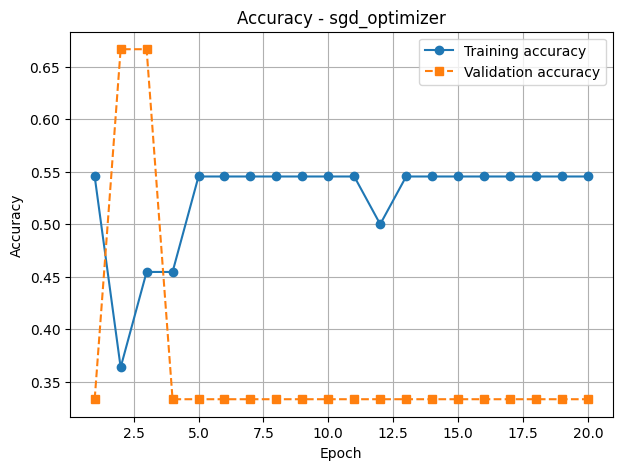

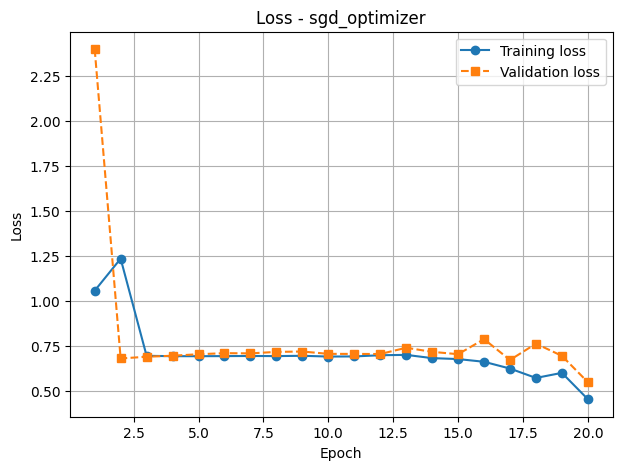

In [12]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

def make_ann(hidden_units=64, second_layer=False, dropout=False):
    model = models.Sequential([
        layers.Input(shape=(200,200,4)),
        layers.Flatten()
    ])
    
    model.add(layers.Dense(hidden_units, activation="relu"))
    
    if second_layer:
        model.add(layers.Dense(32, activation="relu"))
    
    if dropout:
        model.add(layers.Dropout(0.5))

    model.add(layers.Dense(1, activation="sigmoid"))
    
    return model


experiments = {
    "baseline": make_ann(hidden_units=64),
    "more_neurons": make_ann(hidden_units=128),
    "two_layers": make_ann(hidden_units=64, second_layer=True),
    "with_dropout": make_ann(hidden_units=64, dropout=True),
    "sgd_optimizer": make_ann(hidden_units=64)
}

results = {}

for name, model in experiments.items():
    print("\nRunning:", name)

    # Optimizer choice
    if name == "sgd_optimizer":
        model.compile(
            optimizer=tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
            loss="binary_crossentropy",
            metrics=["accuracy"]
        )
    else:
        model.compile(
            optimizer="adam",
            loss="binary_crossentropy",
            metrics=["accuracy"]
        )

    # Train model
    history = model.fit(
        X_train, y_train,
        epochs=20,
        batch_size=8,
        validation_split=0.2,
        verbose=0
    )

    # Evaluate
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    results[name] = acc
    print(f"{name} accuracy: {acc:.4f}")

    #plots
    epochs = range(1, len(history.history["loss"]) + 1)

    # Accuracy plot
    plt.figure(figsize=(7,5))
    plt.plot(epochs, history.history["accuracy"], "o-", label="Training accuracy")
    plt.plot(epochs, history.history["val_accuracy"], "s--", label="Validation accuracy")
    plt.title(f"Accuracy - {name}")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.grid(True)
    plt.legend()
    plt.show()

    # Loss plot
    plt.figure(figsize=(7,5))
    plt.plot(epochs, history.history["loss"], "o-", label="Training loss")
    plt.plot(epochs, history.history["val_loss"], "s--", label="Validation loss")
    plt.title(f"Loss - {name}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.legend()
    plt.show()


Okey from this exercise we can see that we propably too small of a training dataset because the avvuracy and loss varies a lot between epochs so it means the model jus guesses lets try a differnet approach lets take the whole image and split it whole into patches based on urban and forest indices:

we will need to use the 20m resolution for the swir band needed for the indices

In [18]:
from rasterio.warp import reproject, Resampling
folder10 = "/home/scoora/studies/ml/ML_for_space_tech/data/S2A_MSIL2A_20241018T095031_N0511_R079_T34UDA_20241018T124947.SAFE/GRANULE/L2A_T34UDA_A048696_20241018T095240/IMG_DATA/R10m/"

band10_paths = {
    b: glob.glob(f"{folder10}/*_{b}_10m.jp2")[0]
    for b in ["B02", "B03", "B04", "B08"]
}

print("Loaded 10m bands:", band10_paths)

def read10(path):
    with rasterio.open(path) as src:
        return src.read(1).astype(np.float32) / 10000.0, src.transform, src.profile

B02, t10, p10 = read10(band10_paths["B02"])   # Blue 10m
B03, _, _     = read10(band10_paths["B03"])   # Green 10m
B04, _, _     = read10(band10_paths["B04"])   # Red 10m
B08, _, _     = read10(band10_paths["B08"])   # NIR 10m

folder20 = "/home/scoora/studies/ml/ML_for_space_tech/data/S2A_MSIL2A_20241018T095031_N0511_R079_T34UDA_20241018T124947.SAFE/GRANULE/L2A_T34UDA_A048696_20241018T095240/IMG_DATA/R20m/"

B11_path = glob.glob(f"{folder20}/*_B11_20m.jp2")[0]

with rasterio.open(B11_path) as src20:
    B11_20 = src20.read(1).astype(np.float32) / 10000.0
    t20 = src20.transform

# Prepare output array at 10m resolution
H, W = B04.shape
B11_10 = np.zeros((H, W), dtype=np.float32)

# Resample SWIR 20m → 10m grid
reproject(
    B11_20, B11_10,
    src_transform=t20,
    src_crs="EPSG:32634",
    dst_transform=t10,
    dst_crs="EPSG:32634",
    resampling=Resampling.bilinear
)

print("Resampled B11 from 20m to 10m:", B11_10.shape)

# NDVI using true 10m bands
ndvi = (B08 - B04) / (B08 + B04 + 1e-6)

# NDBI using resampled SWIR
ndbi = (B11_10 - B08) / (B11_10 + B08 + 1e-6)

PATCH = 200   # pixels → 200 * 10m = 2 km × 2 km
H, W = ndvi.shape

def get_patch(arr, r, c):
    return arr[r:r+PATCH, c:c+PATCH]

NDVI_FOREST = 0.45  # strong vegetation
NDBI_URBAN  = 0.0   # built-up threshold
NDVI_LOW    = 0.35

def classify_patch(ndvi_p, ndbi_p):
    m_ndvi = np.mean(ndvi_p)
    m_ndbi = np.mean(ndbi_p)

    if m_ndvi > NDVI_FOREST:
        return 0  # forest
    
    if m_ndbi > NDBI_URBAN and m_ndvi < NDVI_LOW:
        return 1  # urban

    return -1


Loaded 10m bands: {'B02': '/home/scoora/studies/ml/ML_for_space_tech/data/S2A_MSIL2A_20241018T095031_N0511_R079_T34UDA_20241018T124947.SAFE/GRANULE/L2A_T34UDA_A048696_20241018T095240/IMG_DATA/R10m/T34UDA_20241018T095031_B02_10m.jp2', 'B03': '/home/scoora/studies/ml/ML_for_space_tech/data/S2A_MSIL2A_20241018T095031_N0511_R079_T34UDA_20241018T124947.SAFE/GRANULE/L2A_T34UDA_A048696_20241018T095240/IMG_DATA/R10m/T34UDA_20241018T095031_B03_10m.jp2', 'B04': '/home/scoora/studies/ml/ML_for_space_tech/data/S2A_MSIL2A_20241018T095031_N0511_R079_T34UDA_20241018T124947.SAFE/GRANULE/L2A_T34UDA_A048696_20241018T095240/IMG_DATA/R10m/T34UDA_20241018T095031_B04_10m.jp2', 'B08': '/home/scoora/studies/ml/ML_for_space_tech/data/S2A_MSIL2A_20241018T095031_N0511_R079_T34UDA_20241018T124947.SAFE/GRANULE/L2A_T34UDA_A048696_20241018T095240/IMG_DATA/R10m/T34UDA_20241018T095031_B08_10m.jp2'}
Resampled B11 from 20m to 10m: (10980, 10980)


In [19]:
X = []
y = []

for r in range(0, H - PATCH, PATCH):
    for c in range(0, W - PATCH, PATCH):

        ndvi_p = get_patch(ndvi, r, c)
        ndbi_p = get_patch(ndbi, r, c)

        label = classify_patch(ndvi_p, ndbi_p)
        if label == -1:
            continue

        R   = get_patch(B04, r, c)
        G   = get_patch(B03, r, c)
        B   = get_patch(B02, r, c)
        NIR = get_patch(B08, r, c)

        patch = np.dstack((R, G, B, NIR))

        if patch.shape != (PATCH, PATCH, 4):
            continue

        X.append(patch)
        y.append(label)

X = np.stack(X)
y = np.array(y, dtype=np.float32)

print("Dataset built:")
print("X shape:", X.shape)
print("Forest:", np.sum(y==0))
print("Urban:", np.sum(y==1))


Dataset built:
X shape: (279, 200, 200, 4)
Forest: 44
Urban: 235


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=0
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)


Train: (223, 200, 200, 4)
Test: (56, 200, 200, 4)



Running: baseline
baseline accuracy: 1.0000


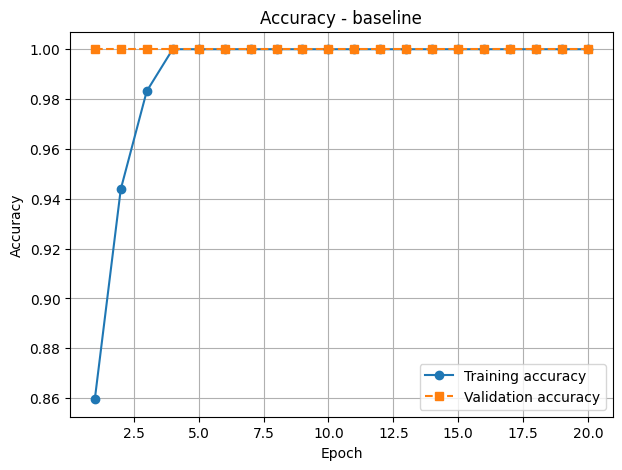

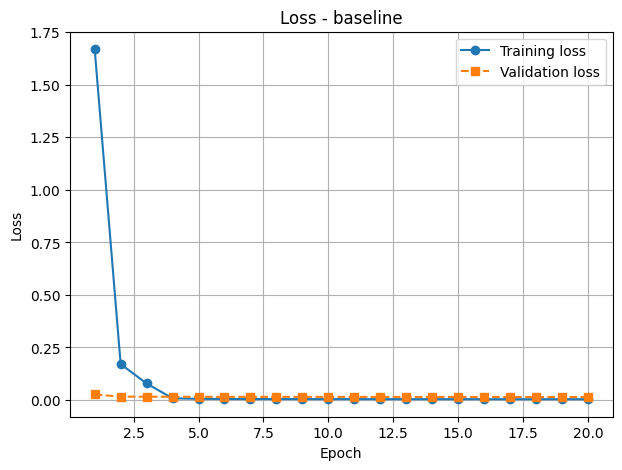


Running: more_neurons
more_neurons accuracy: 1.0000


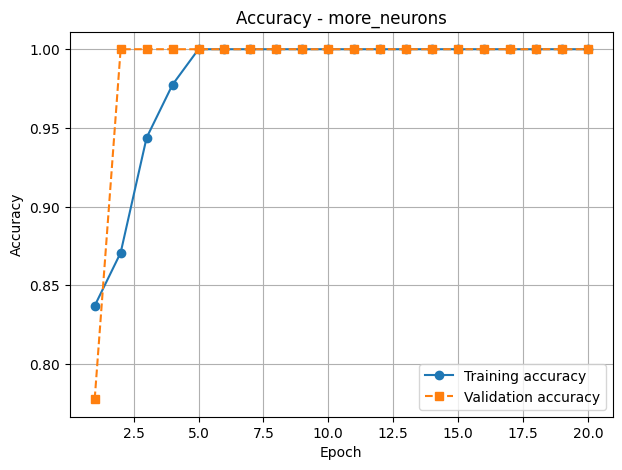

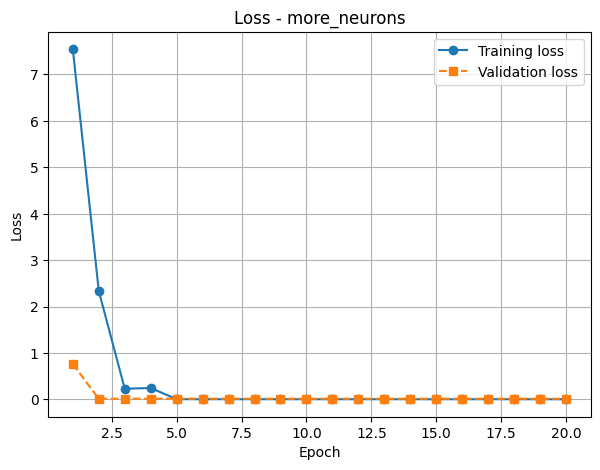


Running: two_layers
two_layers accuracy: 1.0000


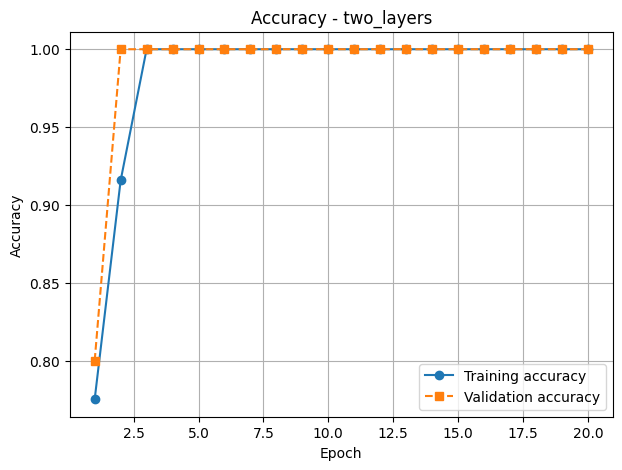

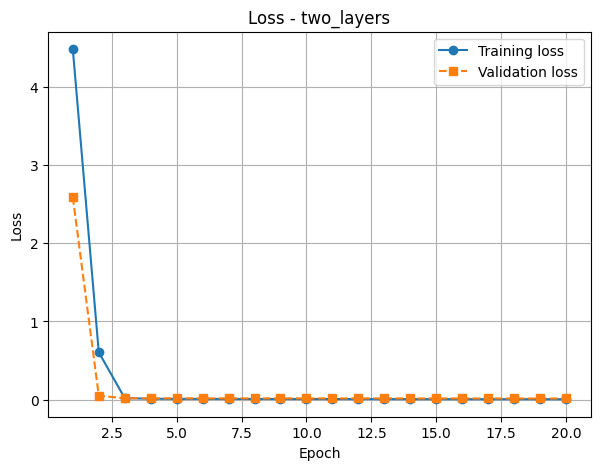


Running: with_dropout
with_dropout accuracy: 0.8393


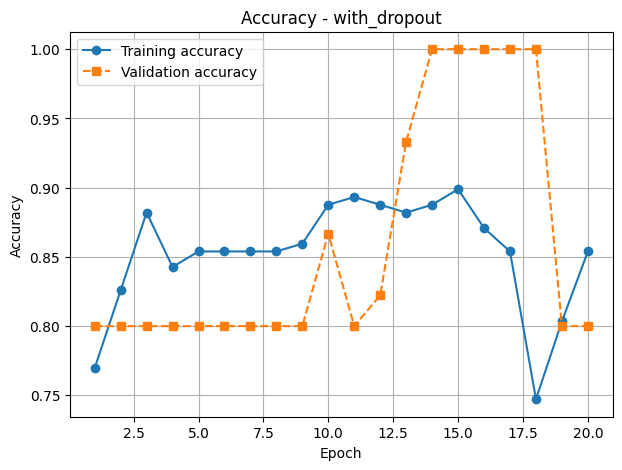

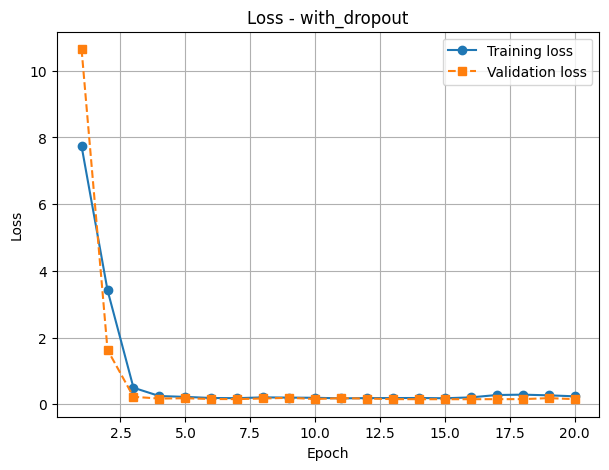


Running: sgd_optimizer
sgd_optimizer accuracy: 1.0000


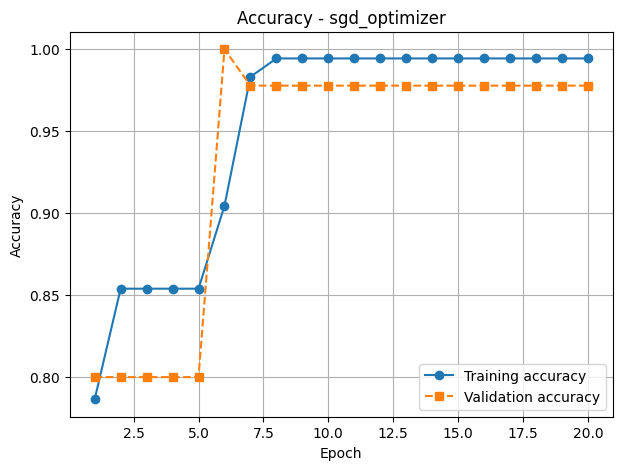

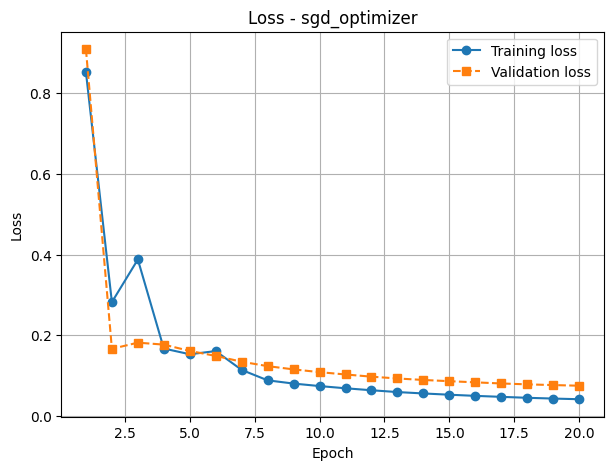

In [21]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

def make_ann(hidden_units=64, second_layer=False, dropout=False):
    model = models.Sequential([
        layers.Input(shape=(200,200,4)),
        layers.Flatten()
    ])
    
    model.add(layers.Dense(hidden_units, activation="relu"))
    
    if second_layer:
        model.add(layers.Dense(32, activation="relu"))
    
    if dropout:
        model.add(layers.Dropout(0.5))

    model.add(layers.Dense(1, activation="sigmoid"))
    
    return model


experiments = {
    "baseline": make_ann(hidden_units=64),
    "more_neurons": make_ann(hidden_units=128),
    "two_layers": make_ann(hidden_units=64, second_layer=True),
    "with_dropout": make_ann(hidden_units=64, dropout=True),
    "sgd_optimizer": make_ann(hidden_units=64)
}

results = {}

for name, model in experiments.items():
    print("\nRunning:", name)

    # Optimizer choice
    if name == "sgd_optimizer":
        model.compile(
            optimizer=tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
            loss="binary_crossentropy",
            metrics=["accuracy"]
        )
    else:
        model.compile(
            optimizer="adam",
            loss="binary_crossentropy",
            metrics=["accuracy"]
        )

    # Train model
    history = model.fit(
        X_train, y_train,
        epochs=20,
        batch_size=8,
        validation_split=0.2,
        verbose=0
    )

    # Evaluate
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    results[name] = acc
    print(f"{name} accuracy: {acc:.4f}")

    #plots
    epochs = range(1, len(history.history["loss"]) + 1)

    # Accuracy plot
    plt.figure(figsize=(7,5))
    plt.plot(epochs, history.history["accuracy"], "o-", label="Training accuracy")
    plt.plot(epochs, history.history["val_accuracy"], "s--", label="Validation accuracy")
    plt.title(f"Accuracy - {name}")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.grid(True)
    plt.legend()
    plt.show()

    # Loss plot
    plt.figure(figsize=(7,5))
    plt.plot(epochs, history.history["loss"], "o-", label="Training loss")
    plt.plot(epochs, history.history["val_loss"], "s--", label="Validation loss")
    plt.title(f"Loss - {name}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.legend()
    plt.show()


Okey this verision worked a lot better the worst one of this 5 cases was the ann with dropout. Of course some of them look al little bit suspicious for example the validation accuracy from firs is always 1, which should be impossible, it is propably due to wrong automatic classification because the set ndvi and ndbi are purely speculative but works for this exercise.